# Dataset


## Setup


### Imports


In [5]:
import os
import subprocess
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Environment


Here we set up the environment for the pipeline. We need to define where the SUMO library is located and add the `bin` and `tools` directories to the system path. This is necessary to be able to use the SUMO tools and libraries in the pipeline.


In [6]:
os.environ["SUMO_HOME"] = os.path.join(os.environ["CONDA_PREFIX"], "Lib", "site-packages", "sumo")

SUMO_HOME = os.environ["SUMO_HOME"]

os.environ["PATH"] += os.pathsep + os.path.join(SUMO_HOME, "bin")
os.environ["PATH"] += os.pathsep + os.path.join(SUMO_HOME, "tools")

### Constants


For the traffic generation periods, we tried to have as realistic as possible traffic patterns. This includes a morning rush hour, a lunch break, and an evening rush hour. A useful reference for traffic patterns in Athens is the [Athens Mobility Observatory](https://amob.ntua.gr/traffic/).


In [ ]:
np.random.seed(42)

DATASET_DIR = os.path.join("athens-osmWebWizard")
OSM_WEB_WIZARD_PATH = os.path.join(SUMO_HOME, "tools", "osmWebWizard.py")
RANDOM_TRIPS_PATH = os.path.join(SUMO_HOME, "tools", "randomTrips.py")
NETWORK_PATH = os.path.join(DATASET_DIR, "osm.net.xml.gz")
DUAROUTER_PATH = os.path.join(SUMO_HOME, "bin", "duarouter.exe")
FCD_TRAIN_DATASET_PATH = os.path.join(DATASET_DIR, "fcd-train-athens-10h.xml")
FCD_TEST_DATASET_PATH = os.path.join(DATASET_DIR, "fcd-test-athens-10h.xml")
XML_2_CSV_PATH = os.path.join(SUMO_HOME, "tools", "xml", "xml2csv.py")
FCD_DRIFT_TRAIN_DATASET_PATH = os.path.join(DATASET_DIR, "fcd-drift-train-athens-10h.xml")
FCD_DRIFT_TEST_DATASET_PATH = os.path.join(DATASET_DIR, "fcd-drift-test-athens-10h.xml")

TRAIN_TRAFFIC_GENERATION_PERIODS = [0.45, 0.50, 0.65, 0.75, 0.80, 0.80, 0.75, 0.55, 0.50, 0.55]
TEST_TRAFFIC_GENERATION_PERIODS = [p * np.random.uniform(0.98, 1.02) for p in TRAIN_TRAFFIC_GENERATION_PERIODS]

## OSM Web Wizard


To generate the network, we can use the [OSM Web Wizard](https://sumo.dlr.de/docs/Tutorials/OSMWebWizard.html). For options, we selected the following:

- Position: Athens (for more details, see `dataset/athens-osmWebWizard/images/athens-map.png`)
- Duration: 36000 (in seconds, effectively 10 hours)
- Add Polygons: Enabled
- Car-only Network: Enabled
- Random Traffic Generation: Disabled All


In [4]:
!python $SUMO_HOME/tools/osmWebWizard.py

^C


## Preparation


### Random Trips


To generate random trips, we can use the [randomTrips.py](https://sumo.dlr.de/docs/Tools/Trip.html) script from the SUMO tools.

This script generates random trips based on the network and the specified parameters. The generated trips are saved in a file that can be used for simulation.

Here, we can specify the network file to use, the beginning and end of the simulation, the traffic generation periods to use, the output file name, a random seed for reproducibility and a flag to validate the trips using `duarouter`.

The traffic generation periods are passed as a comma-separated string. The script will then split the duration of the simulation into equal subintervals and generate trips accordingly.


In [ ]:
def generate_random_trips(prefix, traffic_generation_periods, seed=42, simulation_start=0, simulation_end=36000):
    traffic_generation_periods_str = ",".join(str(v) for v in traffic_generation_periods)
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    routes_temp_file = "routes.rou.xml"

    command = [
        "python",
        RANDOM_TRIPS_PATH,
        "--net-file",
        NETWORK_PATH,
        "--begin",
        str(simulation_start),
        "--end",
        str(simulation_end),
        "--period",
        traffic_generation_periods_str,
        "-o",
        trips_file,
        "--seed",
        str(seed),
        "--validate",
    ]

    print("Executing:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)
    if result.stderr:
        print("Errors/Warnings from randomTrips:")
        print(result.stderr)

    if os.path.exists(trips_file) and os.path.exists(routes_temp_file):
        os.remove(routes_temp_file)
        print("Success:", trips_file)
    else:
        print("Failed:", trips_file)


print("Generating train random trips...")
generate_random_trips("train", TRAIN_TRAFFIC_GENERATION_PERIODS, 42)
print("Generating test random trips...")
generate_random_trips("test", TEST_TRAFFIC_GENERATION_PERIODS, 123)

Generating train random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.45,0.5,0.65,0.75,0.8,0.8,0.75,0.55,0.5,0.55 -o athens-osmWebWizard\train.trips.xml --seed 42 --validate
Success: athens-osmWebWizard\train.trips.xml
Generating test random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.44774172213925256,0.5090142861281983,0.6560318424870966,0.752959754525911,0.788992596494158,0.7889918246507586,0.736742508365046,0.5580558752070487,0.5020223002348642,0.5545775967115131 -o athens-osmWebWizard\test.trips.xml --seed 123 --validate
Success: athens-osmWebWizard\test.trips.xml


### Trip IDs


Some trips are not valid, meaning that they are not able to be routed when using `duarouter`. Here we adjust the trip IDs to be continuous, essentially removing the gaps created by the missing invalid trips.


In [106]:
def update_trip_ids(prefix):
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    if not os.path.exists(trips_file):
        print(f"Trips file not found: {trips_file}")
        return

    tree = ET.parse(trips_file)
    root = tree.getroot()

    trip_id = 0
    for trip in root.findall("trip"):
        trip.set("id", str(trip_id))
        trip_id += 1

    tree.write(trips_file)
    print("Updated:", trips_file)


print("Updating train trip IDs...")
update_trip_ids("train")
print("Updating test trip IDs...")
update_trip_ids("test")

Updating train trip IDs...
Updated: athens-osmWebWizard\train.trips.xml
Updating test trip IDs...
Updated: athens-osmWebWizard\test.trips.xml


### Vehicle Types


For the vehicle types, we ended up going with just cars. We have also defined a few more vehicle types, but they are not used in the dataset. These can be found on the `dataset/athens-osmWebWizard/vtypes.xml` file.

The vehicle types and their parameters, contained in the file above, are based on the following resources:

- [SUMO Vehicle Types](https://sumo.dlr.de/docs/Definition_of_Vehicles,_Vehicle_Types,_and_Routes.html#vehicle_types)
- [SUMO Vehicle Type Parameter Defaults](https://sumo.dlr.de/docs/Vehicle_Type_Parameter_Defaults.html)
- [SUMO HBEFA3-based Emissions](https://sumo.dlr.de/docs/Models/Emissions/HBEFA3-based.html)


In [125]:
def update_vehicle_types(prefix, vehicle_type="car"):
    trips_file = os.path.join(DATASET_DIR, f"{prefix}.trips.xml")
    if not os.path.exists(trips_file):
        print(f"Trips file not found: {trips_file}")
        return

    tree = ET.parse(trips_file)
    root = tree.getroot()

    for trip in root.findall("trip"):
        trip.set("type", vehicle_type)

    tree.write(trips_file)
    print("Updated:", trips_file)


print("Updating train vehicle types...")
update_vehicle_types("train")
print("Updating test vehicle types...")
update_vehicle_types("test")

Updating train vehicle types...
Updated: athens-osmWebWizard\train.trips.xml
Updating test vehicle types...
Updated: athens-osmWebWizard\test.trips.xml


### Fixed Routes


Following, we have defined a few fixed routes. These routes are used on the test dataset, so that we have specific ground truths for visualization and evaluation purposes. These routes are fixed and are not rerouted during the simulation.

The flows, contained in the `dataset/athens-osmWebWizard/fixed.flows.xml` file, were firstly defined using the [netedit](https://sumo.dlr.de/docs/Netedit/index.html) tool of SUMO. For now we only have one trip, with two different routes. The trip is **Omonoia to Evangelismos** and the routes are **via Akadimias** (Route A) and **via Stadiou** (Route B). The routes are as follows:

- **Route A - Via Akadimias**: 23182962 (Stadiou) > 260124786#0 (Akadimias) > 1209362820 (Pl. Filikis Eterias) > 299645496 (Marasli) > 169130585 (Leof. Vasilissis Sofias)
- **Route B - Via Stadiou**: 23182962 (Stadiou) > 299506410#0 (Stadiou) > 221139568 (Leof. Vasilissis Amalias) > -820421378#1 (Leof. Vasilissis Sofias) > 169130585 (Leof. Vasilissis Sofias)

After defining the routes, we can use the `duarouter` tool to generate the fixed routes that will be used in the simulation.


In [4]:
!netedit athens-osmWebWizard/osm.net.xml.gz

In [128]:
def generate_fixed_routes(prefix):
    fixed_flows_file = os.path.join(DATASET_DIR, f"{prefix}.flows.xml")
    fixed_routes_file = os.path.join(DATASET_DIR, f"{prefix}.rou.xml")
    fixed_routes_alt_file = os.path.join(DATASET_DIR, f"{prefix}.rou.alt.xml")

    command = [
        DUAROUTER_PATH,
        "--net-file",
        NETWORK_PATH,
        "--route-files",
        fixed_flows_file,
        "--output-file",
        fixed_routes_file,
    ]

    print("Executing:", " ".join(command))
    result = subprocess.run(command, capture_output=True, text=True)

    if result.stderr:
        print("Errors/Warnings from duarouter:")
        print(result.stderr)

    if os.path.exists(fixed_routes_file) and os.path.exists(fixed_routes_alt_file):
        os.remove(fixed_routes_alt_file)
        print("Success:", fixed_routes_file)
    else:
        print("Failed:", fixed_routes_file)


print("Generating fixed routes...")
generate_fixed_routes("fixed")

Generating fixed routes...
Executing: C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\bin\duarouter.exe --net-file athens-osmWebWizard\osm.net.xml.gz --route-files athens-osmWebWizard\fixed.flows.xml --output-file athens-osmWebWizard\fixed.rou.xml
Success: athens-osmWebWizard\fixed.rou.xml


## Simulation


For the simulation, we can use either the command line [sumo](https://sumo.dlr.de/docs/sumo.html) or launch the [sumo-gui](https://sumo.dlr.de/docs/sumo-gui.html) to have a visual representation of the simulation.


In [109]:
!sumo -c athens-osmWebWizard/train.sumocfg

Loading net-file from 'athens-osmWebWizard/osm.net.xml.gz' ... done (98ms).
Loading additional-files from 'athens-osmWebWizard/osm.poly.xml.gz' ... done (237ms).
Loading additional-files from 'athens-osmWebWizard/vtypes.xml' ... done (2ms).
Loading done.
Simulation version 1.21.0 started with time: 0.00.
Simulation ended at time: 36807.00.
Reason: All vehicles have left the simulation.
Performance:
 Duration: 416.88s
 Real time factor: 88.2924
 UPS: 29794.010689
Vehicles:
 Inserted: 57524
 Running: 0
 Waiting: 0
 Teleports: 106 (Jam: 29, Yield: 62, Wrong Lane: 15)
Statistics (avg of 57524):
 RouteLength: 1736.70
 Speed: 8.35
 Duration: 215.92
 WaitingTime: 43.00
 TimeLoss: 111.77
 DepartDelay: 1.06
DijkstraRouter answered 57593 queries and explored 563.74 edges on average.
DijkstraRouter spent 25.25s answering queries (0.44ms on average).


In [110]:
!sumo -c athens-osmWebWizard/test.sumocfg

Loading net-file from 'athens-osmWebWizard/osm.net.xml.gz' ... done (104ms).
Loading additional-files from 'athens-osmWebWizard/osm.poly.xml.gz' ... done (235ms).
Loading additional-files from 'athens-osmWebWizard/vtypes.xml' ... done (2ms).
Loading done.
Simulation version 1.21.0 started with time: 0.00.
Simulation ended at time: 36595.00.
Reason: All vehicles have left the simulation.
Performance:
 Duration: 423.62s
 Real time factor: 86.3872
 UPS: 29641.991804
Vehicles:
 Inserted: 57506
 Running: 0
 Waiting: 0
 Teleports: 135 (Jam: 40, Yield: 85, Wrong Lane: 10)
 Emergency Braking: 1
Statistics (avg of 57506):
 RouteLength: 1733.21
 Speed: 8.31
 Duration: 218.36
 WaitingTime: 45.50
 TimeLoss: 114.29
 DepartDelay: 1.22
DijkstraRouter answered 57467 queries and explored 564.17 edges on average.
DijkstraRouter spent 26.03s answering queries (0.45ms on average).


## Exploratory Data Analysis


### XML Parsing


Here we parse the XML FCD output generated by the SUMO simulation. The files is converted to csv format for further usage later, but for now we use the XML format for speed and simplicity.


In [111]:
def parse_fcd_output_xml(file_path):
    records = []
    context = ET.iterparse(file_path, events=("end",))
    for _, elem in context:
        if elem.tag == "timestep":
            time = float(elem.get("time"))
            for veh in elem.findall("vehicle"):
                speed_ms = float(veh.get("speed"))
                records.append(
                    {
                        "timestep_time": time,
                        "vehicle_id": veh.get("id"),
                        "x": float(veh.get("x")),
                        "y": float(veh.get("y")),
                        "vehicle_type": veh.get("type"),
                        "speed_kmh": speed_ms * 3.6,
                        "acceleration": float(veh.get("acceleration")),
                        "odometer": float(veh.get("odometer")),
                    }
                )
            elem.clear()
    return pd.DataFrame(records)


print("Parsing train FCD output...")
train_df = parse_fcd_output_xml(FCD_TRAIN_DATASET_PATH)
print("Parsing test FCD output...")
test_df = parse_fcd_output_xml(FCD_TEST_DATASET_PATH)

Parsing train FCD output...
Parsing test FCD output...


### Overview


In [112]:
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

train_df = train_df[train_df["timestep_time"] < 36000].reset_index(drop=True)
test_df = test_df[test_df["timestep_time"] < 36000].reset_index(drop=True)

for df, df_name in [(train_df, "train"), (test_df, "test")]:
    print(f"Dataset: {df_name}")
    print(f"Data shape: {df.shape}")
    print(f"Average speed: {df['speed_kmh'].mean():.2f} km/h")
    print(f"Average distance (max odometer): {df.groupby('vehicle_id')['odometer'].max().mean():.2f} m")
    print(f"Unique vehicles: {df['vehicle_id'].nunique()}")
    print(f"Time span: {df['timestep_time'].min():.2f} s to {df['timestep_time'].max():.2f} s")
    if df_name == "train":
        print()

Dataset: train
Data shape: (12357230, 8)
Average speed: 28.87 km/h
Average distance (max odometer): 1722.65 m
Unique vehicles: 57521
Time span: 0.00 s to 35999.00 s

Dataset: test
Data shape: (12503132, 8)
Average speed: 28.47 km/h
Average distance (max odometer): 1719.79 m
Unique vehicles: 57504
Time span: 0.00 s to 35999.00 s


### Data Engineering


In [113]:
train_df["second"] = train_df["timestep_time"].astype(int)
train_df["hour"] = (train_df["timestep_time"] // 3600).astype(int)
train_secondly = (
    train_df.groupby("second")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)
train_hourly = (
    train_df.groupby("hour")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)

test_df["second"] = test_df["timestep_time"].astype(int)
test_df["hour"] = (test_df["timestep_time"] // 3600).astype(int)
test_secondly = (
    test_df.groupby("second")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)
test_hourly = (
    test_df.groupby("hour")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)

### Speed Distribution


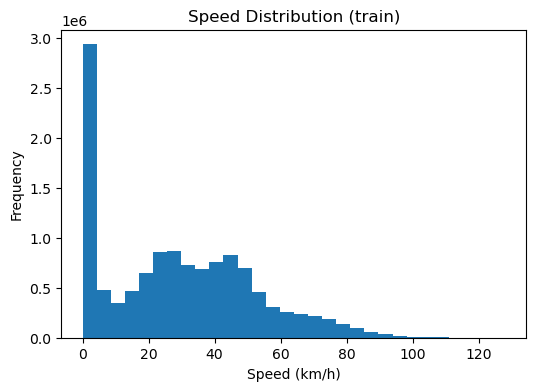

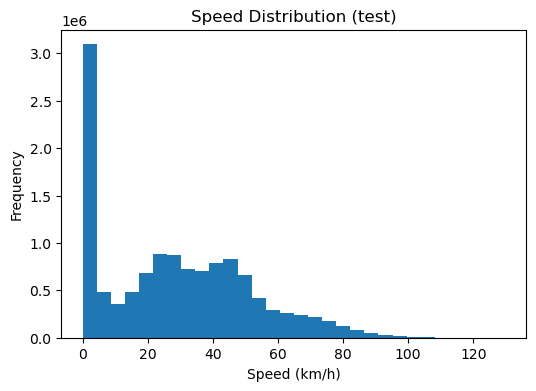

In [114]:
for df, df_name in [(train_df, "train"), (test_df, "test")]:
    plt.figure(figsize=(6, 4))
    plt.hist(df["speed_kmh"], bins=30)
    plt.title(f"Speed Distribution ({df_name})")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Frequency")
    plt.show()

### Average Speed per Second


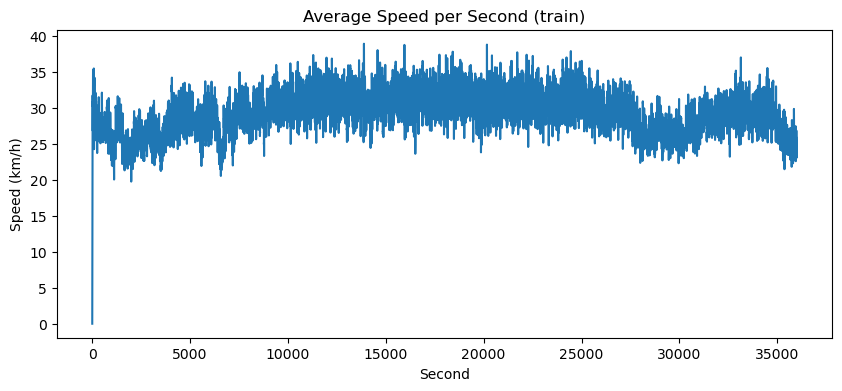

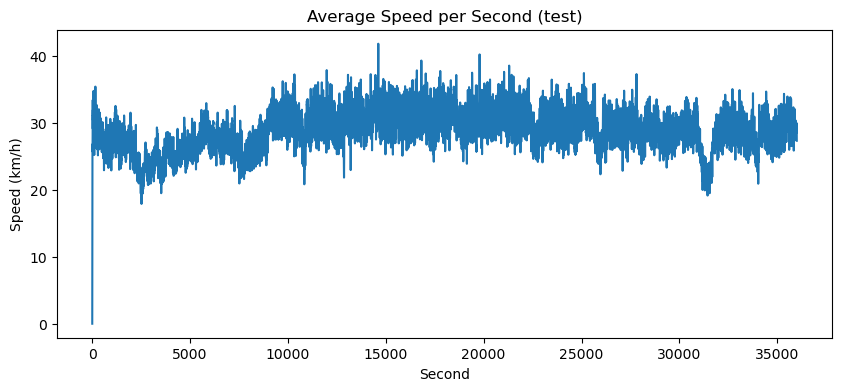

In [115]:
for df, df_name in [(train_secondly, "train"), (test_secondly, "test")]:
    plt.figure(figsize=(10, 4))
    plt.plot(df["second"], df["avg_speed_kmh"])
    plt.title(f"Average Speed per Second ({df_name})")
    plt.xlabel("Second")
    plt.ylabel("Speed (km/h)")
    plt.show()

### Vehicle Count per Second


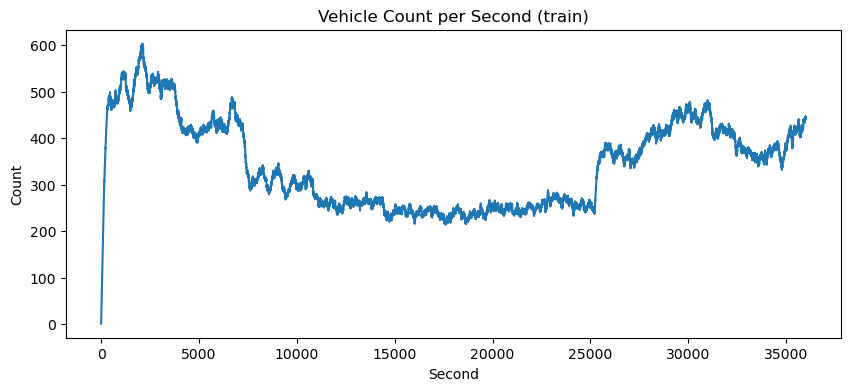

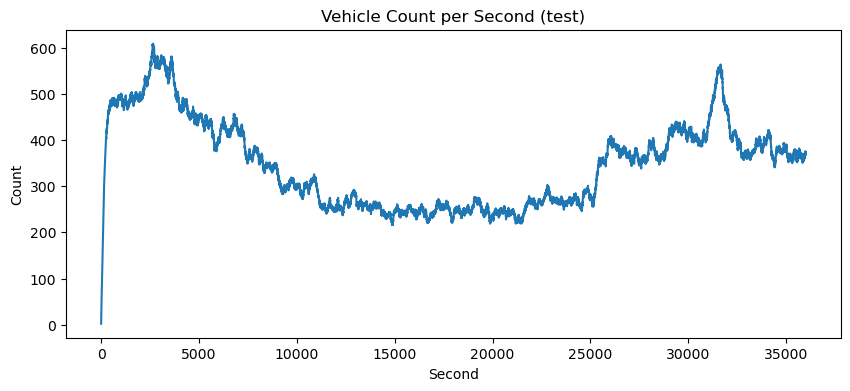

In [116]:
for df, df_name in [(train_secondly, "train"), (test_secondly, "test")]:
    plt.figure(figsize=(10, 4))
    plt.plot(df["second"], df["vehicle_count"])
    plt.title(f"Vehicle Count per Second ({df_name})")
    plt.xlabel("Second")
    plt.ylabel("Count")
    plt.show()

### Average Speed per Hour


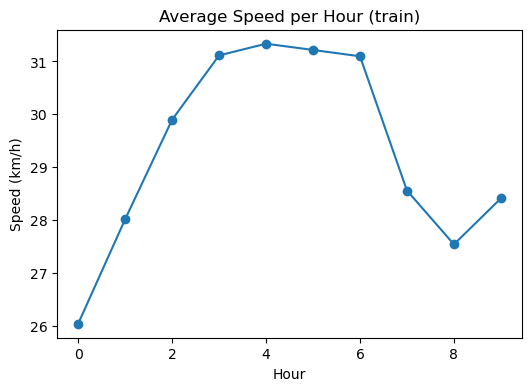

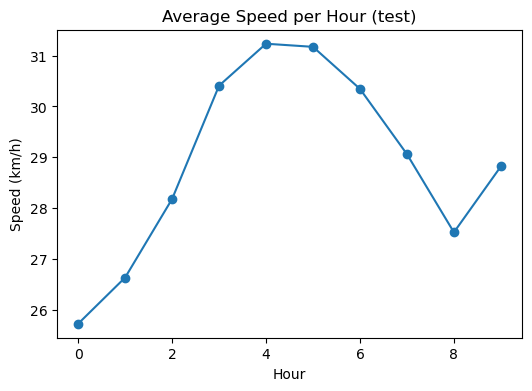

In [117]:
for df, df_name in [(train_hourly, "train"), (test_hourly, "test")]:
    plt.figure(figsize=(6, 4))
    plt.plot(df["hour"], df["avg_speed_kmh"], marker="o")
    plt.title(f"Average Speed per Hour ({df_name})")
    plt.xlabel("Hour")
    plt.ylabel("Speed (km/h)")
    plt.show()

### Vehicle Count per Hour


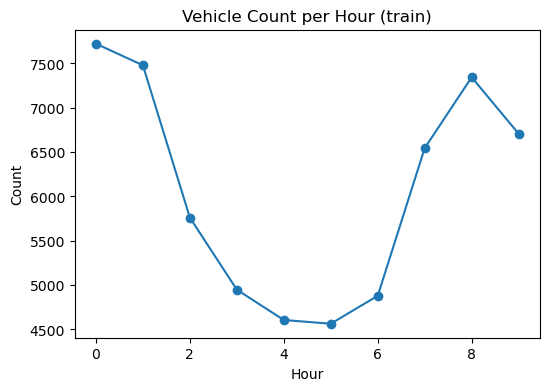

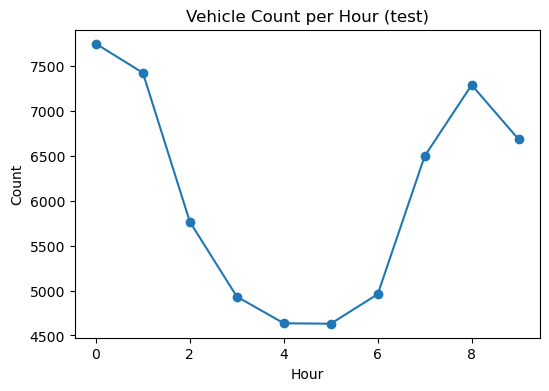

In [118]:
for df, df_name in [(train_hourly, "train"), (test_hourly, "test")]:
    plt.figure(figsize=(6, 4))
    plt.plot(df["hour"], df["vehicle_count"], marker="o")
    plt.title(f"Vehicle Count per Hour ({df_name})")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.show()

### Vehicle Count and Speed over Time


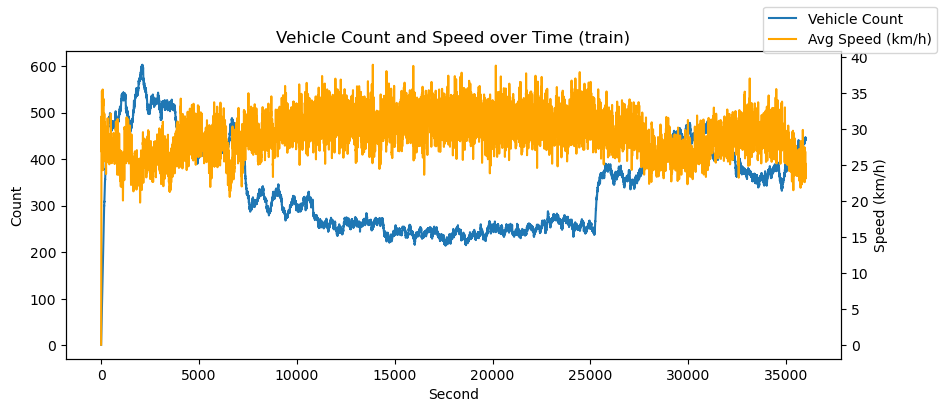

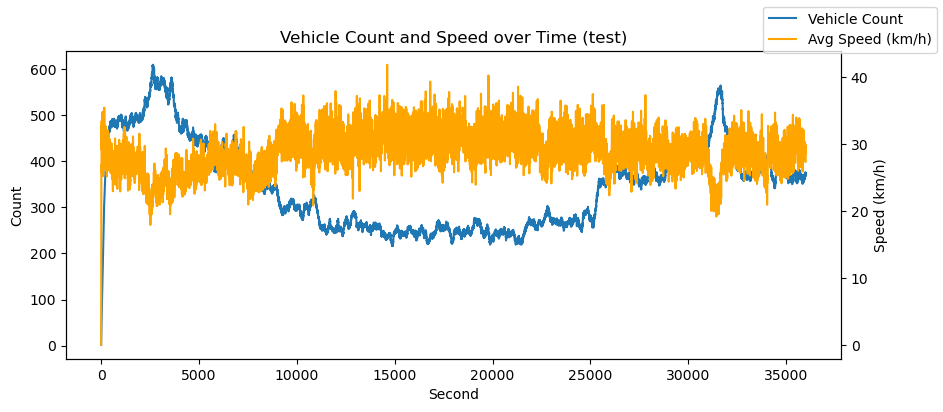

In [119]:
for df, df_name in [(train_secondly, "train"), (test_secondly, "test")]:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df["second"], df["vehicle_count"], label="Vehicle Count")
    ax1.set_xlabel("Second")
    ax1.set_ylabel("Count")
    ax2 = ax1.twinx()
    ax2.plot(df["second"], df["avg_speed_kmh"], label="Avg Speed (km/h)", color="orange")
    ax2.set_ylabel("Speed (km/h)")
    fig.legend(loc="upper right")
    plt.title(f"Vehicle Count and Speed over Time ({df_name})")
    plt.show()

### Average Speed and Traffic Generation Periods per Hour


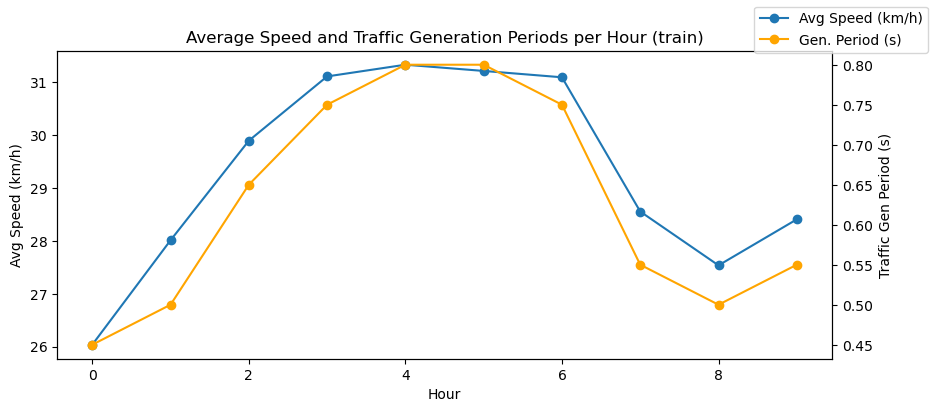

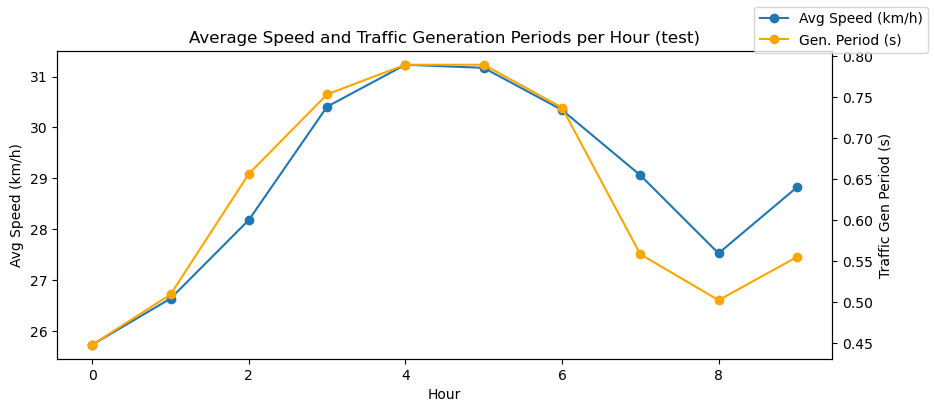

In [120]:
for df, df_name, periods in [
    (train_hourly, "train", TRAIN_TRAFFIC_GENERATION_PERIODS),
    (test_hourly, "test", TEST_TRAFFIC_GENERATION_PERIODS),
]:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df["hour"], df["avg_speed_kmh"], marker="o", label="Avg Speed (km/h)")
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Avg Speed (km/h)")
    ax2 = ax1.twinx()
    ax2.plot(df["hour"], periods, marker="o", label="Gen. Period (s)", color="orange")
    ax2.set_ylabel("Traffic Gen Period (s)")
    fig.legend(loc="upper right")
    plt.title(f"Average Speed and Traffic Generation Periods per Hour ({df_name})")
    plt.show()

## Conversion to CSV


To convert the xml output files to csv, we can use the [xml2csv.py](https://sumo.dlr.de/docs/Tools/Xml.html#xml2csvpy) tool of SUMO.


In [ ]:
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/dump-train-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/emission-train-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/fcd-train-athens-10h.xml

In [ ]:
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/dump-test-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/emission-test-athens-10h.xml
!python $SUMO_HOME/tools/xml/xml2csv.py athens-osmWebWizard/fcd-test-athens-10h.xml

In [ ]:
!rm athens-osmWebWizard/dump-train-athens-10h.xml
!rm athens-osmWebWizard/emission-train-athens-10h.xml
!rm athens-osmWebWizard/fcd-train-athens-10h.xml
!rm athens-osmWebWizard/dump-test-athens-10h.xml
!rm athens-osmWebWizard/emission-test-athens-10h.xml
!rm athens-osmWebWizard/fcd-test-athens-10h.xml

## Concept Drift


1. Disable single edge (road closure)
1. Disable multiple edges (cycling event)
1. Disable single lane (accident)
1. Disable multiple lanes (road works)
1. Increase of traffic on certain area (concert or football match)
1. Increase of traffic on whole area (holidays)
1. Reduction of traffic on certain area (shut down of a factory)
1. Reduction of traffic on whole area (holidays)
1. Global reduction of speed (weather)
1. Global increase of vehicle following gaps (weather)
1. Global decrease of acceleration (weather)
1. Global increase of deceleration (weather)

For 1-4 we can use an additional file named `closures.add.xml` that contains the edge/lane closures. This file can be then added to the additional files of the simulation as follows:

```xml
<additional-files value="osm.poly.xml.gz, vtypes.xml, closures.add.xml"/>
```

For 9-12 we can use a new vehicle type called `car-rain` that has the following changes:

- `accel` = 2.0 (default is 2.6)
- `decel` = 4.0 (default is 4.5)
- `minGap` = 3.5 (default is 2.5)
- `maxSpeed` = 33.33 (default is 55.55)
- `speedFactor` = 0.8 (default is 1.0)


In [121]:
print("Generating drift train random trips...")
generate_random_trips("drift-train", TRAIN_TRAFFIC_GENERATION_PERIODS, 42)
print("Generating drift test random trips...")
generate_random_trips("drift-test", TEST_TRAFFIC_GENERATION_PERIODS, 123)

Generating drift train random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.45,0.5,0.65,0.75,0.8,0.8,0.75,0.55,0.5,0.55 -o athens-osmWebWizard\drift-train.trips.xml --seed 42 --validate
Success: athens-osmWebWizard\drift-train.trips.xml
Generating drift test random trips...
Executing: python C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\tools\randomTrips.py --net-file athens-osmWebWizard\osm.net.xml.gz --begin 0 --end 36000 --period 0.44774172213925256,0.5090142861281983,0.6560318424870966,0.752959754525911,0.788992596494158,0.7889918246507586,0.736742508365046,0.5580558752070487,0.5020223002348642,0.5545775967115131 -o athens-osmWebWizard\drift-test.trips.xml --seed 123 --validate
Success: athens-osmWebWizard\drift-test.trips.xml


In [122]:
print("Updating drift train trip IDs...")
update_trip_ids("drift-train")
print("Updating drift test trip IDs...")
update_trip_ids("drift-test")

Updating drift train trip IDs...
Updated: athens-osmWebWizard\drift-train.trips.xml
Updating drift test trip IDs...
Updated: athens-osmWebWizard\drift-test.trips.xml


In [127]:
print("Updating drift train vehicle types...")
update_vehicle_types("drift-train", "car-rain")
print("Updating drift test vehicle types...")
update_vehicle_types("drift-test", "car-rain")

Updating drift train vehicle types...
Updated: athens-osmWebWizard\drift-train.trips.xml
Updating drift test vehicle types...
Updated: athens-osmWebWizard\drift-test.trips.xml


In [129]:
print("Generating drift fixed routes...")
generate_fixed_routes("drift-fixed")

Generating drift fixed routes...
Executing: C:\Users\george\miniconda3\envs\thesis\Lib\site-packages\sumo\bin\duarouter.exe --net-file athens-osmWebWizard\osm.net.xml.gz --route-files athens-osmWebWizard\drift-fixed.flows.xml --output-file athens-osmWebWizard\drift-fixed.rou.xml
Success: athens-osmWebWizard\drift-fixed.rou.xml


In [140]:
!sumo -c athens-osmWebWizard/drift-train.sumocfg

^C


In [ ]:
!sumo -c athens-osmWebWizard/drift-test.sumocfg

Loading net-file from 'athens-osmWebWizard/osm.net.xml.gz' ... done (103ms).
Loading additional-files from 'athens-osmWebWizard/osm.poly.xml.gz' ... done (236ms).
Loading additional-files from 'athens-osmWebWizard/vtypes.xml' ... done (2ms).
Loading additional-files from 'athens-osmWebWizard/closures.add.xml' ...
Loading of additional-files failed.


Error: Attribute 'to' is missing in definition of edge '167920360#1'.
Error: Attribute 'from' is missing in definition of edge '167920360#1'.
Error: Attribute 'to' is missing in definition of edge '23182965#0'.
Error: Attribute 'from' is missing in definition of edge '23182965#0'.
Error: Attribute 'to' is missing in definition of edge '207979569#0'.
Error: Attribute 'from' is missing in definition of edge '207979569#0'.
Error: Attribute 'to' is missing in definition of edge '207979569#3'.
Error: Attribute 'from' is missing in definition of edge '207979569#3'.
Error: Attribute 'to' is missing in definition of edge '168914464#0'.
Error: Attribute 'from' is missing in definition of edge '168914464#0'.
Error: Attribute 'to' is missing in definition of edge '167907746#0'.
Error: Attribute 'from' is missing in definition of edge '167907746#0'.
Error: Attribute 'to' is missing in definition of edge '704293238'.
Error: Attribute 'from' is missing in definition of edge '704293238'.
Error: Attri

In [ ]:
print("Parsing drift train FCD output...")
drift_train_df = parse_fcd_output_xml(FCD_DRIFT_TRAIN_DATASET_PATH)
print("Parsing drift test FCD output...")
drift_test_df = parse_fcd_output_xml(FCD_DRIFT_TEST_DATASET_PATH)

In [ ]:
drift_train_df = drift_train_df.dropna().reset_index(drop=True)
drift_test_df = drift_test_df.dropna().reset_index(drop=True)

drift_train_df = drift_train_df[drift_train_df["timestep_time"] < 36000].reset_index(drop=True)
drift_test_df = drift_test_df[drift_test_df["timestep_time"] < 36000].reset_index(drop=True)

for df, df_name in [(drift_train_df, "drift-train"), (drift_test_df, "drift-test")]:
    print(f"Dataset: {df_name}")
    print(f"Data shape: {df.shape}")
    print(f"Average speed: {df['speed_kmh'].mean():.2f} km/h")
    print(f"Average distance (max odometer): {df.groupby('vehicle_id')['odometer'].max().mean():.2f} m")
    print(f"Unique vehicles: {df['vehicle_id'].nunique()}")
    print(f"Time span: {df['timestep_time'].min():.2f} s to {df['timestep_time'].max():.2f} s")
    if df_name == "drift-train":
        print()

In [ ]:
drift_train_df["second"] = drift_train_df["timestep_time"].astype(int)
drift_train_df["hour"] = (drift_train_df["timestep_time"] // 3600).astype(int)
drift_train_secondly = (
    drift_train_df.groupby("second")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)
drift_train_hourly = (
    drift_train_df.groupby("hour")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)

drift_test_df["second"] = drift_test_df["timestep_time"].astype(int)
drift_test_df["hour"] = (drift_test_df["timestep_time"] // 3600).astype(int)
drift_test_secondly = (
    drift_test_df.groupby("second")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)
drift_test_hourly = (
    drift_test_df.groupby("hour")
    .agg(avg_speed_kmh=("speed_kmh", "mean"), vehicle_count=("vehicle_id", "nunique"))
    .reset_index()
)

In [ ]:
for df, df_name in [(drift_train_df, "drift-train"), (drift_test_df, "drift-test")]:
    plt.figure(figsize=(6, 4))
    plt.hist(df["speed_kmh"], bins=30)
    plt.title(f"Speed Distribution ({df_name})")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
for df, df_name in [(drift_train_secondly, "drift-train"), (drift_test_secondly, "drift-test")]:
    plt.figure(figsize=(10, 4))
    plt.plot(df["second"], df["avg_speed_kmh"])
    plt.title(f"Average Speed per Second ({df_name})")
    plt.xlabel("Second")
    plt.ylabel("Speed (km/h)")
    plt.show()

In [ ]:
for df, df_name in [(drift_train_secondly, "drift-train"), (drift_test_secondly, "drift-test")]:
    plt.figure(figsize=(10, 4))
    plt.plot(df["second"], df["vehicle_count"])
    plt.title(f"Vehicle Count per Second ({df_name})")
    plt.xlabel("Second")
    plt.ylabel("Count")
    plt.show()

In [ ]:
for df, df_name in [(drift_train_hourly, "drift-train"), (drift_test_hourly, "drift-test")]:
    plt.figure(figsize=(6, 4))
    plt.plot(df["hour"], df["avg_speed_kmh"], marker="o")
    plt.title(f"Average Speed per Hour ({df_name})")
    plt.xlabel("Hour")
    plt.ylabel("Speed (km/h)")
    plt.show()

In [ ]:
for df, df_name in [(drift_train_hourly, "drift-train"), (drift_test_hourly, "drift-test")]:
    plt.figure(figsize=(6, 4))
    plt.plot(df["hour"], df["vehicle_count"], marker="o")
    plt.title(f"Vehicle Count per Hour ({df_name})")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.show()

In [ ]:
for df, df_name in [(drift_train_secondly, "drift-train"), (drift_test_secondly, "drift-test")]:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df["second"], df["vehicle_count"], label="Vehicle Count")
    ax1.set_xlabel("Second")
    ax1.set_ylabel("Count")
    ax2 = ax1.twinx()
    ax2.plot(df["second"], df["avg_speed_kmh"], label="Avg Speed (km/h)", color="orange")
    ax2.set_ylabel("Speed (km/h)")
    fig.legend(loc="upper right")
    plt.title(f"Vehicle Count and Speed over Time ({df_name})")
    plt.show()

In [ ]:
for df, df_name, periods in [
    (drift_train_hourly, "drift-train", TRAIN_TRAFFIC_GENERATION_PERIODS),
    (drift_test_hourly, "drift-test", TEST_TRAFFIC_GENERATION_PERIODS),
]:
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(df["hour"], df["avg_speed_kmh"], marker="o", label="Avg Speed (km/h)")
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Avg Speed (km/h)")
    ax2 = ax1.twinx()
    ax2.plot(df["hour"], periods, marker="o", label="Gen. Period (s)", color="orange")
    ax2.set_ylabel("Traffic Gen Period (s)")
    fig.legend(loc="upper right")
    plt.title(f"Average Speed and Traffic Generation Periods per Hour ({df_name})")
    plt.show()